In [31]:
import pandas as pd
import numpy as np

churn_df = pd.read_pickle("Output/churn_df.pkl")
future_features = pd.read_pickle("Output/future_features.pkl")
true_future_predictions = np.load("Output/true_future_predictions.npy")

In [32]:
master_df = pd.read_pickle("Dataset/Cleaned_data/master_df.pkl")
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CustomerID             52924 non-null  str           
 1   Transaction_ID         52924 non-null  str           
 2   Transaction_Date       52924 non-null  datetime64[us]
 3   Month                  52924 non-null  str           
 4   Date                   52924 non-null  object        
 5   Week                   52924 non-null  str           
 6   Product_SKU            52924 non-null  str           
 7   Product_Description    52924 non-null  str           
 8   Product_Category       52924 non-null  str           
 9   ABC                    52924 non-null  str           
 10  Quantity               52924 non-null  int64         
 11  Avg_Price              52924 non-null  float64       
 12  Delivery_Charges       52924 non-null  float64       
 13  Revenue     

In [36]:
# ensure CustomerID columns have the same dtype
print(churn_df['CustomerID'].dtype, future_features['CustomerID'].dtype)

churn_df['CustomerID'] = churn_df['CustomerID'].astype(str)
future_features['CustomerID'] = future_features['CustomerID'].astype(str)

str int64


In [37]:
# Build customer intelligence table from churn + CLV outputs

customer_table = churn_df[[
    'CustomerID',
    'Churn_Segment',
    'Churn_Probability',
    'frequency_cal',
    'monetary_sum'
]].copy()

future_clv_df = pd.DataFrame({
    'CustomerID': future_features['CustomerID'],
    'Predicted_CLV': true_future_predictions
})

customer_table = customer_table.merge(
    future_clv_df,
    on='CustomerID',
    how='left'
)

customer_table = customer_table.rename(columns={
    'CustomerID': 'Customer_ID',
    'Churn_Segment': 'Segment',
    'frequency_cal': 'Frequency',
    'monetary_sum': 'Monetary'
})

customer_table = customer_table[
    ['Customer_ID', 'Segment', 'Predicted_CLV',
     'Churn_Probability', 'Frequency', 'Monetary']
]

customer_table.head()

,Customer_ID,Segment,Predicted_CLV,Churn_Probability,Frequency,Monetary
0,12346,High Risk,1521.856717,0.940,1,24.98174
1,12347,Low Risk,1696.204653,0.195,1,12467.81216
2,12348,Low Risk,667.509332,0.050,1,776.21724
3,12356,High Risk,1443.527043,0.955,1,1369.93900
4,12359,High Risk,1568.932527,0.895,1,688.03320


### Revenue at Risk Analysis

Nếu một customer có CLV cao và churn probability cao → revenue đang bị đe dọa.

Current customer churn behavior puts approximately ${...} in future revenue at risk.

In [38]:
# =========================================================
# REVENUE AT RISK
# =========================================================

customer_table["Revenue_At_Risk"] = (
    customer_table["Predicted_CLV"] *
    customer_table["Churn_Probability"]
)

total_revenue_risk = customer_table["Revenue_At_Risk"].sum()

print(
    f"Estimated Revenue At Risk: "
    f"${total_revenue_risk:,.2f}"
)

Estimated Revenue At Risk: $563,768.75


## Strategic Customer Classification

Phân khách thành 4 business groups.

In [39]:
# =========================================================
# CUSTOMER STRATEGY CLASSIFICATION
# =========================================================

clv_threshold = customer_table["Predicted_CLV"].median()
churn_threshold = 0.50


def assign_strategy(row):

    high_clv = row["Predicted_CLV"] >= clv_threshold
    high_churn = row["Churn_Probability"] >= churn_threshold

    if high_clv and high_churn:
        return "Critical Retention"

    elif high_clv and not high_churn:
        return "Loyal Growth"

    elif not high_clv and high_churn:
        return "Low Cost Retention"

    else:
        return "Nurture"


customer_table["Strategy_Group"] = customer_table.apply(
    assign_strategy,
    axis=1
)

customer_table[
    ["Customer_ID", "Strategy_Group"]
].head()

,Customer_ID,Strategy_Group
0,12346,Critical Retention
1,12347,Loyal Growth
2,12348,Loyal Growth
3,12356,Critical Retention
4,12359,Critical Retention


## Next Best Action Engine

Đây là phần biến analytics thành decision.

In [40]:
# =========================================================
# NEXT BEST ACTION ENGINE
# =========================================================

def recommend_action(row):

    strategy = row["Strategy_Group"]

    if strategy == "Critical Retention":
        return "VIP retention campaign"

    elif strategy == "Loyal Growth":
        return "Upsell premium products"

    elif strategy == "Low Cost Retention":
        return "Automated discount email"

    else:
        return "Educational nurturing content"


customer_table["Recommended_Action"] = customer_table.apply(
    recommend_action,
    axis=1
)

## Executive Dashboard Table

In [41]:
# =========================================================
# EXECUTIVE BUSINESS SUMMARY
# =========================================================

executive_summary = customer_table.groupby(
    "Strategy_Group"
).agg({

    "Customer_ID": "count",
    "Predicted_CLV": "mean",
    "Churn_Probability": "mean",
    "Revenue_At_Risk": "sum"

}).round(2)

executive_summary.columns = [

    "Customer_Count",
    "Avg_CLV",
    "Avg_Churn_Risk",
    "Total_Revenue_Risk"

]

executive_summary = executive_summary.sort_values(
    by="Total_Revenue_Risk",
    ascending=False
)

executive_summary

,Customer_Count,Avg_CLV,Avg_Churn_Risk,Total_Revenue_Risk
Strategy_Group,,,,
Critical Retention,378,1547.07,0.85,498377.70
Loyal Growth,228,1291.25,0.19,60241.62
Nurture,50,333.18,0.19,3107.67
Low Cost Retention,555,4.40,0.99,2041.76


In [42]:
# =========================================================
# AUTOMATED INSIGHT GENERATION
# =========================================================

critical_group = customer_table[
    customer_table["Strategy_Group"] == "Critical Retention"
]

critical_pct = (
    len(critical_group) /
    len(customer_table)
) * 100

critical_risk_pct = (
    critical_group["Revenue_At_Risk"].sum() /
    customer_table["Revenue_At_Risk"].sum()
) * 100


print(
    f"{critical_pct:.1f}% of customers belong to the "
    f"Critical Retention group, but they account for "
    f"{critical_risk_pct:.1f}% of total revenue risk."
)

31.2% of customers belong to the Critical Retention group, but they account for 88.4% of total revenue risk.


## Campaign ROI Simulation

Nếu giữ lại được 20% nhóm nguy hiểm nhất:

In [43]:
# =========================================================
# RETENTION CAMPAIGN SIMULATION
# =========================================================

retention_success_rate = 0.20

recoverable_revenue = (
    critical_group["Revenue_At_Risk"].sum()
    * retention_success_rate
)

print(
    f"Potential recoverable revenue: "
    f"${recoverable_revenue:,.2f}"
)

Potential recoverable revenue: $99,675.54


## Visualization

### Customer Strategy Quadrant

Biểu đồ này thường xuất hiện trong consulting deck.

X-axis = Churn Risk
Y-axis = Predicted CLV

=> nhìn phát biết:

Top Right = khách VIP nhưng sắp churn → cứu ngay

Top Left = khách VIP loyal → upsell

Bottom Right = churn nhưng low value → automate

Bottom Left = nurture

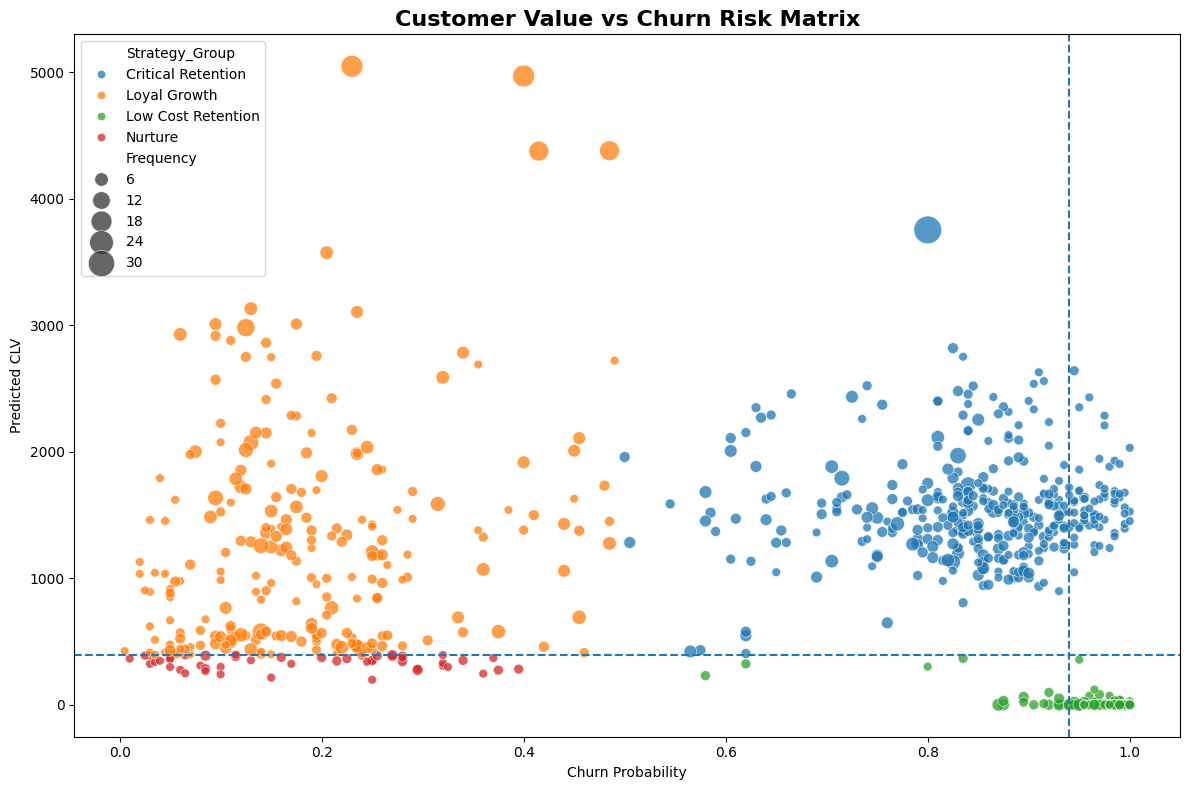

In [44]:
# =========================================================
# CUSTOMER STRATEGY QUADRANT
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=customer_table,
    x="Churn_Probability",
    y="Predicted_CLV",
    hue="Strategy_Group",
    size="Frequency",
    sizes=(40, 400),
    alpha=0.75
)

# threshold lines
plt.axvline(
    customer_table["Churn_Probability"].median(),
    linestyle='--'
)

plt.axhline(
    customer_table["Predicted_CLV"].median(),
    linestyle='--'
)

plt.title(
    "Customer Value vs Churn Risk Matrix",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Churn Probability")
plt.ylabel("Predicted CLV")

plt.tight_layout()
plt.show()

### Executive Revenue Risk Chart

Câu hỏi business:

“Nhóm nào đang làm doanh nghiệp mất nhiều tiền nhất?”

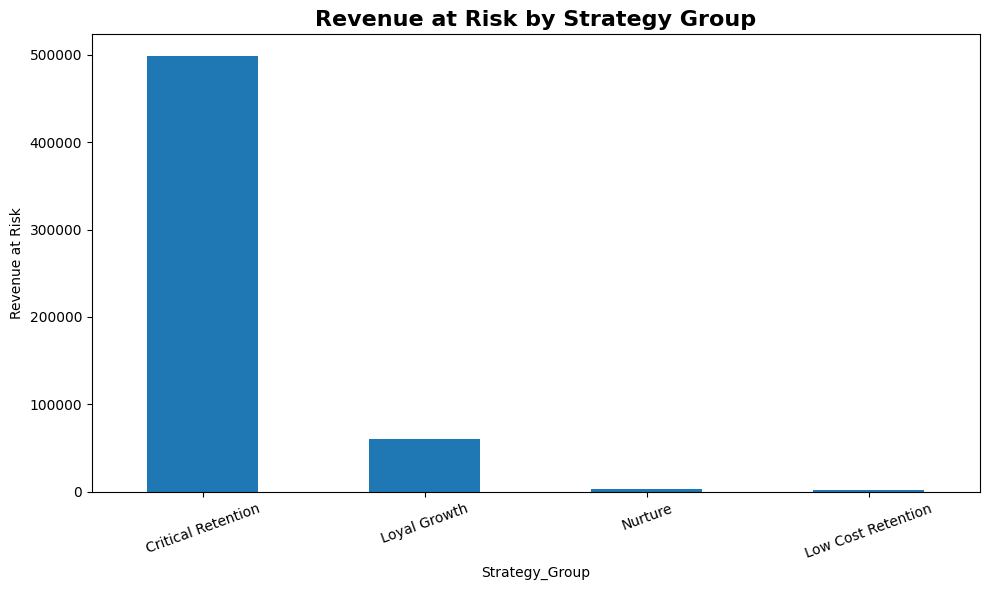

In [45]:
# =========================================================
# EXECUTIVE REVENUE RISK
# =========================================================

strategy_risk = customer_table.groupby(
    "Strategy_Group"
)["Revenue_At_Risk"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

strategy_risk.plot(
    kind='bar'
)

plt.title(
    "Revenue at Risk by Strategy Group",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Revenue at Risk")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Customer Count vs Revenue Risk

=> Nhóm đông chưa chắc quan trọng nhất.

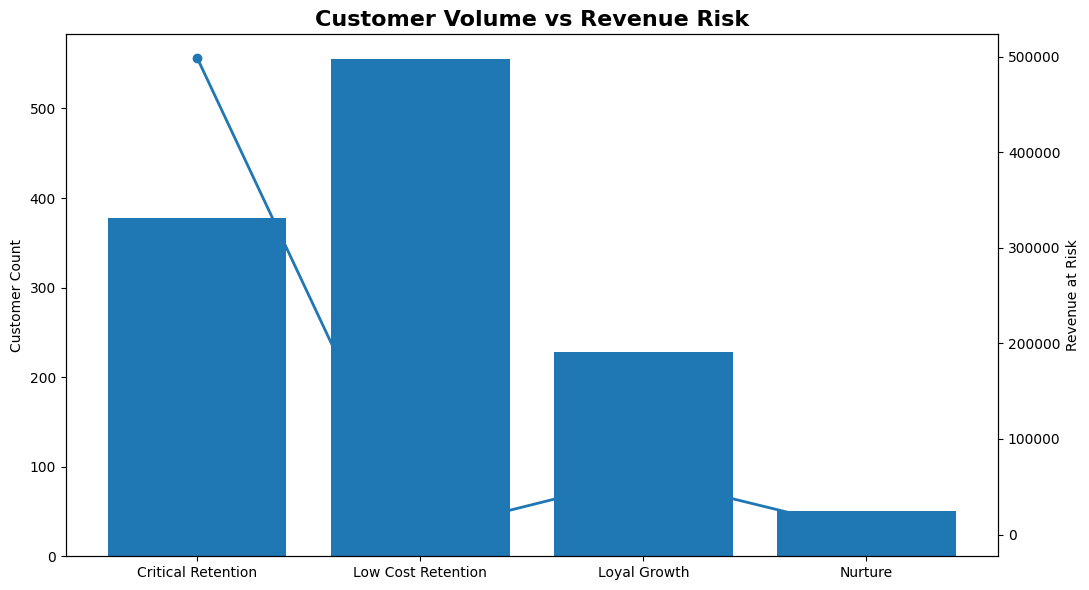

In [46]:
# =========================================================
# CUSTOMER COUNT VS BUSINESS VALUE
# =========================================================

dashboard = customer_table.groupby(
    "Strategy_Group"
).agg({

    "Customer_ID":"count",
    "Revenue_At_Risk":"sum"

}).reset_index()

fig, ax1 = plt.subplots(figsize=(11,6))

# customer count
ax1.bar(
    dashboard["Strategy_Group"],
    dashboard["Customer_ID"]
)

ax1.set_ylabel("Customer Count")

# revenue risk
ax2 = ax1.twinx()

ax2.plot(
    dashboard["Strategy_Group"],
    dashboard["Revenue_At_Risk"],
    marker='o',
    linewidth=2
)

ax2.set_ylabel("Revenue at Risk")

plt.title(
    "Customer Volume vs Revenue Risk",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Segment Profitability Heatmap

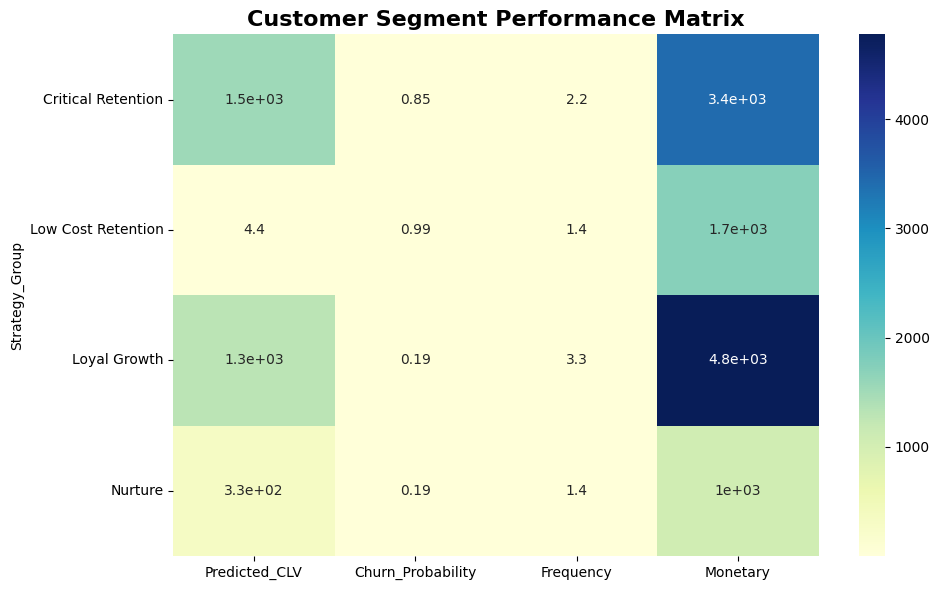

In [47]:
# =========================================================
# SEGMENT PERFORMANCE HEATMAP
# =========================================================

heatmap_data = customer_table.groupby(
    "Strategy_Group"
).agg({

    "Predicted_CLV":"mean",
    "Churn_Probability":"mean",
    "Frequency":"mean",
    "Monetary":"mean"

}).round(2)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "Customer Segment Performance Matrix",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()